In [ ]:
import os
import sys

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/cax-control"))

from shadowpy.cax_simulation import CAXSim
from caxscripts.image_statistics import Histogram2DAnalyzer
# from Shadow import histo
import numpy as np
import matplotlib.pyplot as plt
from shadowpy.utils import save_image

In [2]:
cax = CAXSim(total_rays=1000000)


 Generated        50000  rays out of      1000000
                 100000
                 150000
                 200000
                 250000
                 300000
                 350000
                 400000
                 450000
                 500000
                 550000
                 600000
                 650000
                 700000
                 750000
                 800000
                 850000
                 900000
                 950000
                1000000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
Traced through element 1: M1
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


/home/gabriel.amici/repos/cax-scripts/caxscripts/image_statistics.py:121: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()
/home/gabriel.amici/repos/cax-control/shadowpy/shadowpy/utils.py:197: UserWarning: Beam not visible; skipping momenta analysis.
  ana.compute_momenta()


Traced through element 2: DVF_A1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
Traced through element 3: DVF_B1
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


Text(0.5, 1.0, 'Image at source ($z = 0$ m)')

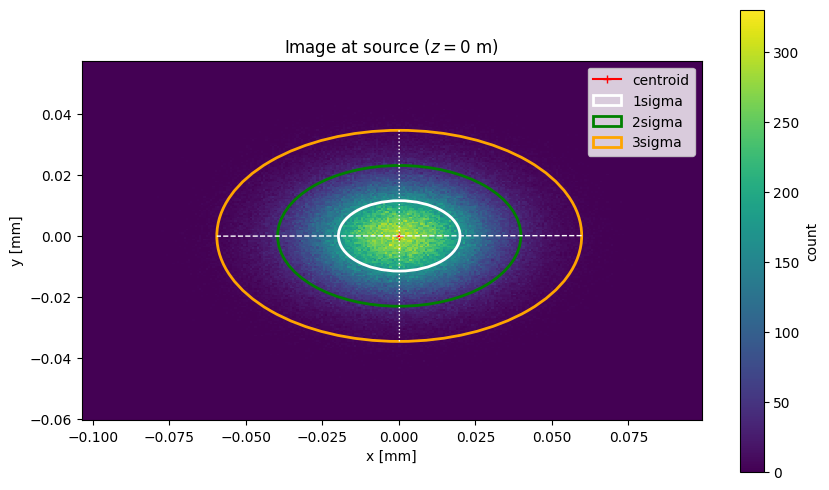

In [3]:
ana_source = cax.source.image

fig, ax = plt.subplots(figsize=(10, 6))
fig, ax = ana_source.plot( fig=fig, ax=ax )
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Image at source ($z = 0$ m)")

In [4]:
# Propagated
source_beam = cax.beams[0].duplicate()
source_beam.retrace(17000) #17 m
ana_at_mirror = save_image(cax.source, source_beam)

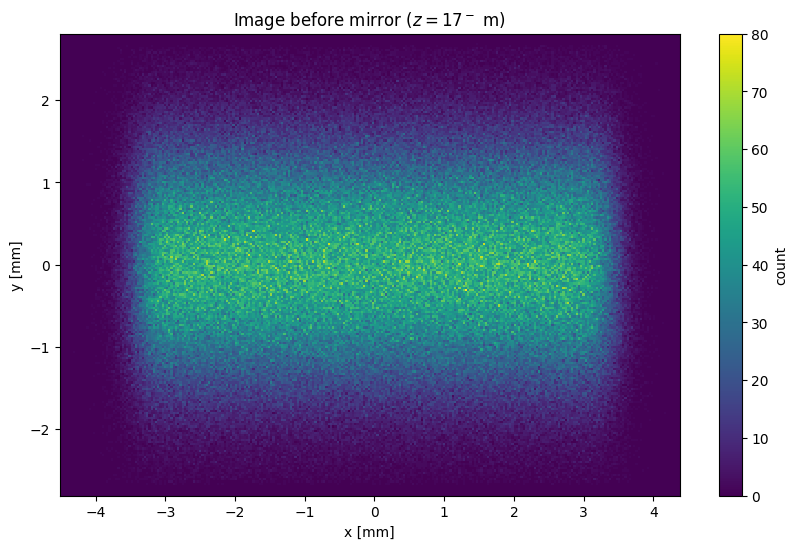

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
m = ax.pcolormesh(
            ana_at_mirror.x_bin_edges, ana_at_mirror.y_bin_edges, ana_at_mirror.img.T,
            shading="auto", cmap="viridis",
        )
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
plt.colorbar(m, ax=ax, label="count")
ax.set_title("Image before mirror ($z = 17^-$ m)")
plt.show()

In [15]:
image_ticket.keys()

dict_keys(['error', 'col_h', 'col_v', 'nolost', 'nbins_h', 'nbins_v', 'ref', 'xrange', 'yrange', 'bin_h_edges', 'bin_v_edges', 'bin_h_left', 'bin_v_left', 'bin_h_right', 'bin_v_right', 'bin_h_center', 'bin_v_center', 'histogram', 'histogram_h', 'histogram_v', 'intensity', 'nrays', 'good_rays', 'fwhm_h', 'fwhm_coordinates_h', 'fwhm_v', 'fwhm_coordinates_v'])

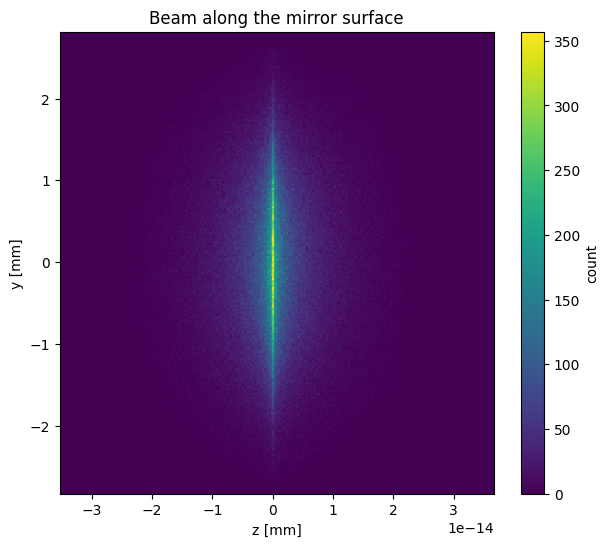

In [17]:
mirror_beam = cax.mirror.beam.duplicate()

image_ticket = mirror_beam.histo2(col_h=2, col_v=1, 
                                   nbins_h=280, nbins_v=210, 
                                   nolost=1)

histogram   = image_ticket["histogram"]
bin_h_centers = image_ticket["bin_h_center"]
bin_v_centers = image_ticket["bin_v_center"]

fig, ax = plt.subplots(figsize=(7, 6))
m = ax.pcolormesh(
            bin_h_centers, bin_v_centers, histogram.T,
            shading="auto", cmap="viridis",
        )
ax.set_xlabel("z [mm]")
ax.set_ylabel("y [mm]")
plt.colorbar(m, ax=ax, label="count")
ax.set_title("Beam along the mirror surface")
plt.show()

In [6]:
# Propagated
mirror_beam = cax.mirror.beam.duplicate()
# source_beam.retrace(17000) #17 m
ana_after_mirror = save_image(cax.mirror, mirror_beam)

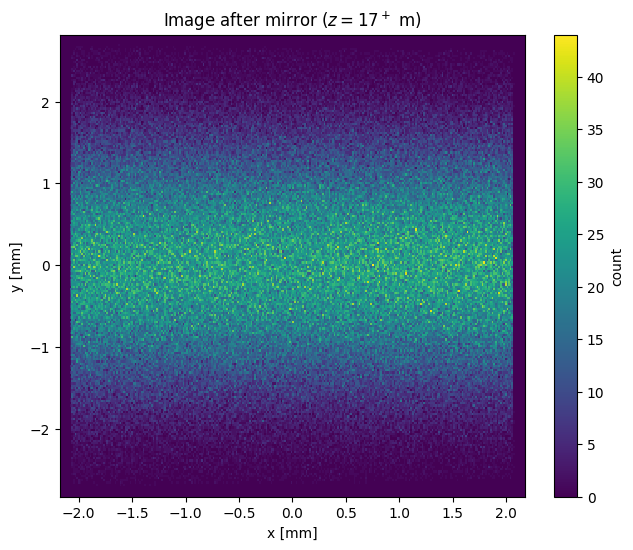

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6))
m = ax.pcolormesh(
            ana_after_mirror.x_bin_edges, ana_after_mirror.y_bin_edges, ana_after_mirror.img.T,
            shading="auto", cmap="viridis",
        )
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
plt.colorbar(m, ax=ax, label="count")
ax.set_title("Image after mirror ($z = 17^+$ m)")
plt.show()

In [8]:
cax.dvf_A1.source_distance

4359.0

In [9]:
# Propagated
slit_beam = cax.mirror.beam.duplicate()
slit_beam.retrace(4359)
# source_beam.retrace(17000) #17 m
ana_before_slit = save_image(cax.dvf_A1, slit_beam)

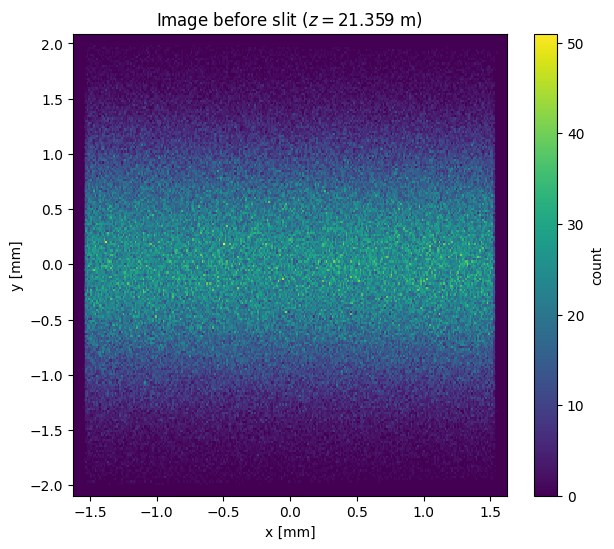

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
m = ax.pcolormesh(
            ana_before_slit.x_bin_edges, ana_before_slit.y_bin_edges, ana_before_slit.img.T,
            shading="auto", cmap="viridis",
        )
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
plt.colorbar(m, ax=ax, label="count")
ax.set_title("Image before slit ($z = 21.359$ m)")
plt.show()

In [11]:
cax.mirror.ry = -0.1

Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
Traced through element 2: DVF_A1
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 3: DVF_B1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR


Text(0.5, 1.0, 'Image at screen ($z = 34$ m)')

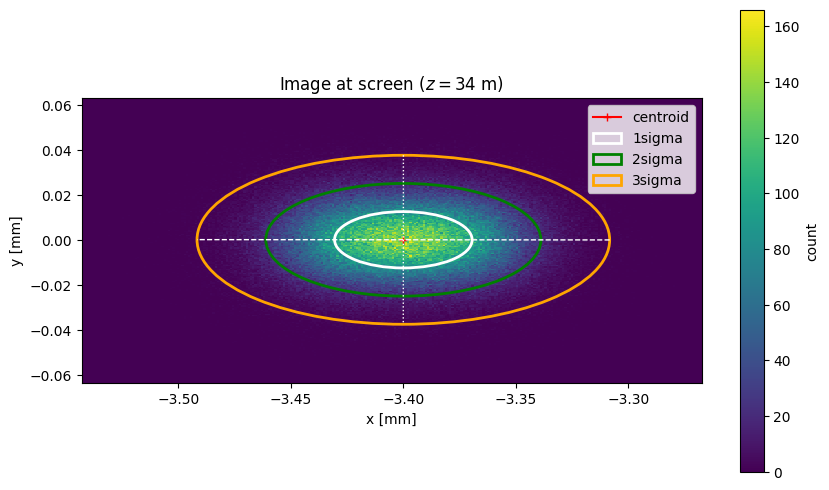

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
fig, ax = cax.dvf_B1.image.plot(fig=fig, ax=ax)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Image at screen ($z = 34$ m)")

In [ ]:
cx = cax.dvf_B1.image.hprm_project['mux']
cy = cax.dvf_B1.image.hprm_project['muy']
# cx, cy = cy, cx

fx = cax.dvf_B1.image.hprm_project['fwhmx']
fy = cax.dvf_B1.image.hprm_project['fwhmy']

cax.dvf_B1.image.img[cx, cy]
print(cx, cy)
np.unravel_index(cax.dvf_B1.image.img.argmax(), cax.dvf_B1.image.img.shape)


In [ ]:
cax.dvf_B1.image.x_bin_centers[cx]

In [ ]:
cax.dvf_B1.image.qck_intensity(cax.dvf_B1.image.img, (cx, cy), (fx, fy), 1)

In [ ]:
image_ticket = cax.dvf_B1.beam.histo2(col_h=3, col_v=1, 
                            nbins_h=280, nbins_v=210, nolost=1)

In [ ]:
hist = np.array(image_ticket['histogram'])
h_centers = np.array(image_ticket['bin_h_center'])
v_centers = np.array(image_ticket['bin_v_center'])

In [ ]:
cax.dvf_B1.image.plot(hprm=cax.dvf_B1.image.hprm_momenta)

In [ ]:
from optlnls.plot import plot_beam


In [ ]:
x = h_centers
y = v_centers
img = hist

beam2D_2 = np.zeros((len(y)+1, len(x)+1))
beam2D_2[0,1:] = x
beam2D_2[1:,0] = y
beam2D_2[1:,1:] = img.T


plot_beam(beam2D_2, cut=0, textA=1, textB=10, textC=9, textD=0, fitType=1,
          plot_title='CAX M1 nominal', show_colorbar=1,
            x_range=1, y_range=1, x_range_min=-0.12, x_range_max=0.12, y_range_min=-0.12, y_range_max=0.12,
          zero_pad_x=1, zero_pad_y=1, cmap='viridis', integral=1e11,
          units=2)


In [ ]:
x = cax.dvf_B1.image.x_bin_centers
y = cax.dvf_B1.image.y_bin_centers
img = cax.dvf_B1.image.img

beam2D = np.zeros((len(y)+1, len(x)+1))
beam2D[0,1:] = x
beam2D[1:,0] = y
beam2D[1:,1:] = img.T


plot_beam(beam2D, cut=0, textA=1, textB=10, textC=3, textD=0, fitType=1,
          plot_title='CAX M1 nominal', show_colorbar=1,
            x_range=1, y_range=1, x_range_min=-0.12, x_range_max=0.12, y_range_min=-0.12, y_range_max=0.12,
          zero_pad_x=1, zero_pad_y=1, cmap='viridis', integral=1e11,
          units=2)


In [ ]:
print(cax.dvf_B1.image.hprm_fitting['mux']*1000)
print(cax.dvf_B1.image.hprm_fitting['muy']*1000)

In [ ]:
cax.dvf_B1.image.print_stats(cax.dvf_B1.image.hprm_fitting)

In [ ]:
cax.dvf_B1.image.img.shape